# Jute Pest Image Classification (Transfer Learning) — Analysis Notebook

## Objective
This notebook analyzes the results of a transfer-learning pipeline for **multi-class jute pest image classification** (17 classes).  
Training and artifact generation are performed via `src/main.py`. This notebook focuses on:

- Comparing pretrained backbones (**EfficientNetB0, VGG16, DenseNet201**) using saved metrics
- Selecting a final model (EfficientNetB0)
- Inspecting learning curves and per-class performance using saved reports

> Note: This notebook does **not** retrain models. It reads the outputs saved in `results/`.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook is located at: <repo_root>/notebook/analysis.ipynb
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"

print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("RESULTS_DIR exists:", RESULTS_DIR.exists())

PROJECT_ROOT exists: True
RESULTS_DIR exists: True


In [2]:
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_text(path: Path) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def parse_classification_report(text: str) -> pd.DataFrame:
    """
    Parses a sklearn classification_report (text) into a DataFrame.
    Returns per-class rows (precision, recall, f1, support).
    """
    lines = [ln.rstrip() for ln in text.splitlines() if ln.strip()]
    header_idx = None
    for i, ln in enumerate(lines):
        if "precision" in ln and "recall" in ln and "f1-score" in ln and "support" in ln:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Could not find report header.")

    data_lines = lines[header_idx + 1:]
    rows = []
    for ln in data_lines:
        if ln.strip().startswith("accuracy"):
            break
        parts = re.split(r"\s{2,}", ln.strip())
        if len(parts) != 5:
            continue
        cls, prec, rec, f1, sup = parts
        rows.append((cls, float(prec), float(rec), float(f1), int(float(sup))))

    df = pd.DataFrame(rows, columns=["class", "precision", "recall", "f1", "support"])
    return df


## Dataset & Problem Context

- Dataset: **Jute Pest Dataset** (UCI Machine Learning Repository)
- Task: **17-class** image classification of common jute pests
- Directory format: `train/`, `val/`, `test/` with class-named subfolders

### Why macro metrics?
Because classes can be uneven in size (especially in validation), this analysis emphasizes **macro precision/recall/F1** (treats each class equally) and **macro AUC**.


## Methodology Overview (Pipeline)

### Transfer Learning
Three pretrained CNN backbones were compared using the same classification head:

- EfficientNetB0
- VGG16
- DenseNet201

### Training configuration
- Image size: 224×224
- Batch size: 16
- Max epochs: 30 (with early stopping)
- Patience: 5
- Learning rate: 1e-4
- Seed: 42

This setup matches the final configuration used in `src/config.py`


In [3]:
comparison_path = RESULTS_DIR / "models_comparison.csv"
df_cmp = pd.read_csv(comparison_path)

# Order columns for readability
key_cols = [
    "model",
    "val_f1_macro", "val_auc_macro",
    "test_f1_macro", "test_auc_macro",
    "train_f1_macro"
]
display(df_cmp[key_cols].sort_values("val_f1_macro", ascending=False))


,model,val_f1_macro,val_auc_macro,test_f1_macro,test_auc_macro,train_f1_macro
2,DenseNet201,0.863000,0.992765,0.978481,0.999519,0.992931
0,EfficientNetB0,0.861672,0.994348,0.986511,0.999943,0.994839
1,VGG16,0.833834,0.969291,0.980940,0.999638,0.982033


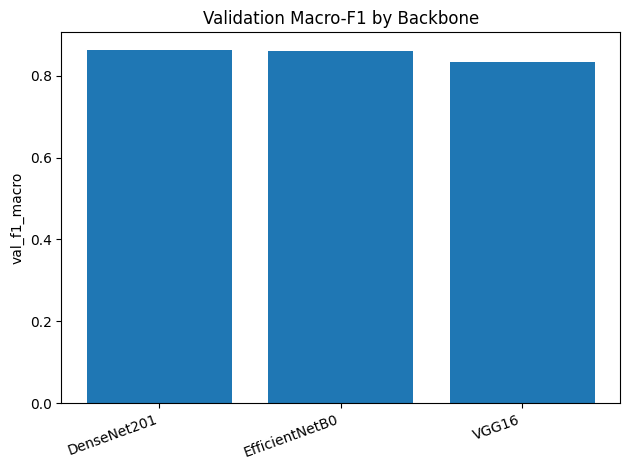

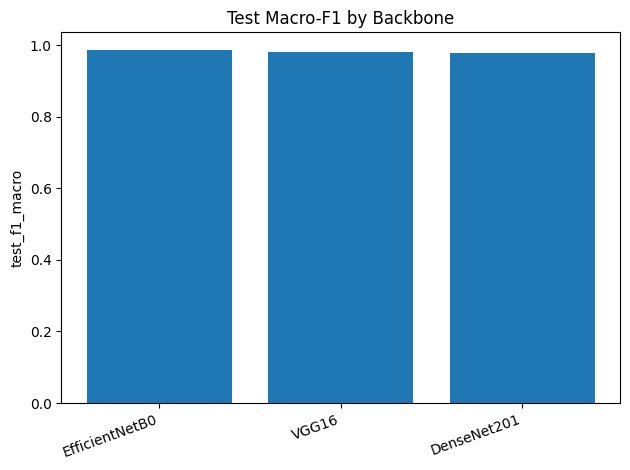

In [4]:
def barplot_metric(df: pd.DataFrame, metric: str, title: str):
    df_sorted = df.sort_values(metric, ascending=False)
    plt.figure()
    plt.bar(df_sorted["model"], df_sorted[metric])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(title)
    plt.tight_layout()
    plt.show()

barplot_metric(df_cmp, "val_f1_macro", "Validation Macro-F1 by Backbone")
barplot_metric(df_cmp, "test_f1_macro", "Test Macro-F1 by Backbone")


## Model Selection Decision

### Observation
- **DenseNet201** achieves the best **validation macro-F1** by a small margin.
- **EfficientNetB0** achieves the best **test macro-F1** and is **faster to train**.

From the comparison table:
- EfficientNetB0 test macro-F1 ≈ 0.9865
- DenseNet201 test macro-F1 ≈ 0.9785
- Validation macro-F1 is very close (DenseNet201 slightly ahead)



### Decision
I select **EfficientNetB0** as the final model because:
1. It performs best on the held-out **test** split (proxy for real-world generalization)
2. It is more compute-efficient (faster training) while maintaining strong accuracy
3. The differences across models are small overall, so efficiency is a meaningful tie-breaker


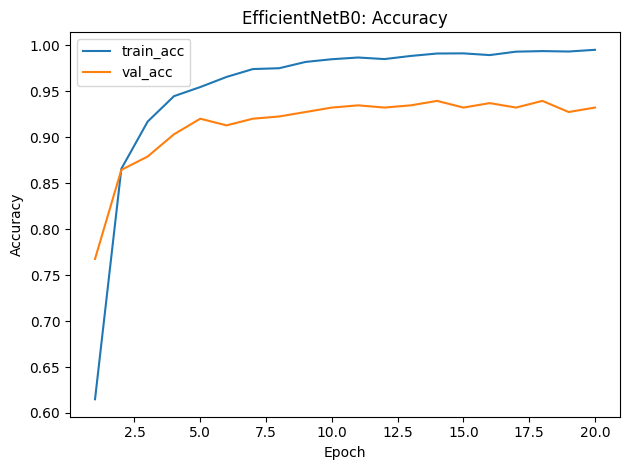

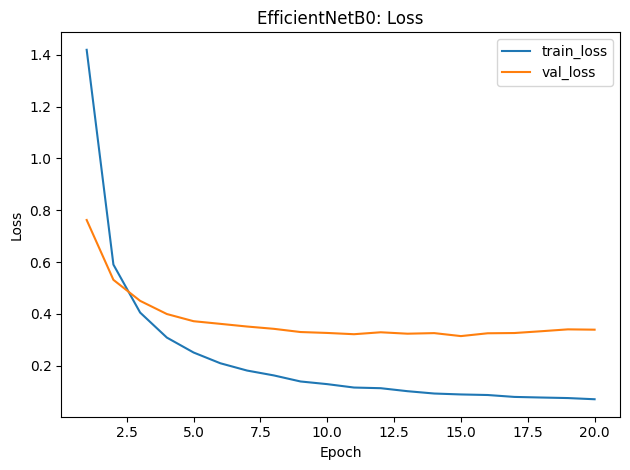

Best val_accuracy epoch: 14 val_accuracy: 0.9394673109054565
Min val_loss: 0.31422868371009827


In [5]:
backbone = "EfficientNetB0"
bb_dir = RESULTS_DIR / backbone

hist_path = bb_dir / "history.json"
hist = load_json(hist_path)

epochs = np.arange(1, len(hist["accuracy"]) + 1)

plt.figure()
plt.plot(epochs, hist["accuracy"], label="train_acc")
plt.plot(epochs, hist["val_accuracy"], label="val_acc")
plt.title(f"{backbone}: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs, hist["loss"], label="train_loss")
plt.plot(epochs, hist["val_loss"], label="val_loss")
plt.title(f"{backbone}: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

best_val_epoch = int(np.argmax(hist["val_accuracy"]) + 1)
best_val_acc = float(np.max(hist["val_accuracy"]))
best_val_loss = float(np.min(hist["val_loss"]))
print("Best val_accuracy epoch:", best_val_epoch, "val_accuracy:", best_val_acc)
print("Min val_loss:", best_val_loss)


In [6]:
train_rep_path = bb_dir / "EfficientNetB0_Train_classification_report.txt"
val_rep_path   = bb_dir / "EfficientNetB0_Val_classification_report.txt"
test_rep_path  = bb_dir / "EfficientNetB0_Test_classification_report.txt"

train_rep = read_text(train_rep_path)
val_rep   = read_text(val_rep_path)
test_rep  = read_text(test_rep_path)

df_train = parse_classification_report(train_rep)
df_val   = parse_classification_report(val_rep)
df_test  = parse_classification_report(test_rep)

print("Validation: lowest F1 classes")
display(df_val.sort_values("f1", ascending=True).head(6))

print("Validation: highest F1 classes")
display(df_val.sort_values("f1", ascending=False).head(6))


Validation: lowest F1 classes


,class,precision,recall,f1,support
12,Pod Borer,0.00,0.00,0.00,3
7,Jute Semilooper,0.57,0.80,0.67,5
5,Jute Hairy,0.75,0.75,0.75,8
14,Termite,0.95,0.77,0.85,26
4,Jute Aphid,0.86,0.89,0.87,27
0,Beet Armyworm,0.94,0.82,0.88,40


Validation: highest F1 classes


,class,precision,recall,f1,support
8,Jute Stem Girdler,1.00,1.00,1.00,6
13,Scopula Emissaria,1.00,1.00,1.00,6
9,Jute Stem Weevil,0.99,1.00,0.99,71
6,Jute Red Mite,0.98,0.98,0.98,49
1,Black Hairy,0.97,1.00,0.98,30
16,Yellow Mite,1.00,0.97,0.98,30


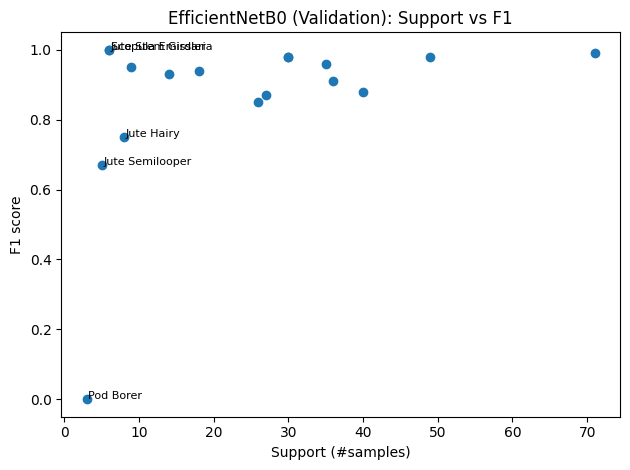

In [7]:
plt.figure()
plt.scatter(df_val["support"], df_val["f1"])
for _, row in df_val.sort_values("support").head(5).iterrows():
    plt.text(row["support"] + 0.2, row["f1"], row["class"], fontsize=8)
plt.title(f"{backbone} (Validation): Support vs F1")
plt.xlabel("Support (#samples)")
plt.ylabel("F1 score")
plt.tight_layout()
plt.show()


## Train / Validation / Test Summary (EfficientNetB0)

- **Train**: accuracy ≈ 0.99, macro-F1 ≈ 0.99 
- **Validation**: accuracy ≈ 0.93, macro-F1 ≈ 0.86   
- **Test**: accuracy ≈ 0.99, macro-F1 ≈ 0.99  

### Interpretation
- The model fits the training data extremely well.
- Validation macro performance is lower primarily due to **small validation supports for some classes**, making macro-F1 more sensitive.
- Test performance is strong and consistent with the overall pipeline quality.


## Conclusions

### Key findings
- All three backbones perform strongly and are close overall.
- DenseNet201 leads slightly on validation macro-F1, but EfficientNetB0 leads on test macro-F1 and trains faster. 
- EfficientNetB0 learning curves show fast convergence and stable validation behavior.

### Final model
**EfficientNetB0** is selected as the final model due to its strong test performance and compute efficiency.

